In [2]:
import pandas as pd
import glob

# Aseguramos que agarre los 5 archivos automáticamente
archivos = sorted(glob.glob('mexico-city-real-estate-*.csv'))
print("Archivos encontrados:", archivos)

Archivos encontrados: ['mexico-city-real-estate-1.csv', 'mexico-city-real-estate-2.csv', 'mexico-city-real-estate-3.csv', 'mexico-city-real-estate-4.csv', 'mexico-city-real-estate-5.csv']


In [3]:
# Cargamos cada uno y revisamos si tienen las mismas columnas antes de concatenar
dfs = [pd.read_csv(archivo) for archivo in archivos]

for i, d in enumerate(dfs, start=1):
    print(f"Archivo {i}: shape={d.shape}, columnas={list(d.columns)}")

Archivo 1: shape=(4628, 16), columnas=['operation', 'property_type', 'place_with_parent_names', 'lat-lon', 'price', 'currency', 'price_aprox_local_currency', 'price_aprox_usd', 'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2', 'price_per_m2', 'floor', 'rooms', 'expenses', 'properati_url']
Archivo 2: shape=(4628, 16), columnas=['operation', 'property_type', 'place_with_parent_names', 'lat-lon', 'price', 'currency', 'price_aprox_local_currency', 'price_aprox_usd', 'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2', 'price_per_m2', 'floor', 'rooms', 'expenses', 'properati_url']
Archivo 3: shape=(4628, 16), columnas=['operation', 'property_type', 'place_with_parent_names', 'lat-lon', 'price', 'currency', 'price_aprox_local_currency', 'price_aprox_usd', 'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2', 'price_per_m2', 'floor', 'rooms', 'expenses', 'properati_url']
Archivo 4: shape=(4628, 16), columnas=['operation', 'property_type', 'place_

In [4]:
# Si todos tienen las mismas columnas, los unimos
df = pd.concat(dfs, ignore_index=True)
print(df.shape)
df.head()

(23140, 16)


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,"23.634501,-102.552788",5500000.0,MXN,5450245.50,289775.66,NaN,54.0,NaN,101851.851900,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/o3zb...
1,sell,house,|Iztapalapa|Distrito Federal|México|,"19.31033,-99.068557",1512000.0,MXN,1498321.97,79661.96,NaN,80.0,NaN,18900.000000,NaN,NaN,NaN,http://iztapalapa.properati.com.mx/q7t0_venta_...
2,sell,apartment,|Tlalpan|Distrito Federal|México|,"19.279771,-99.234597",926667.0,MXN,918284.00,48822.82,NaN,100.0,NaN,9266.670000,NaN,NaN,NaN,http://tlalpan.properati.com.mx/qbi4_venta_dep...
3,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,"23.634501,-102.552788",6410000.0,MXN,6352013.39,337720.36,NaN,135.0,NaN,47481.481480,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/opeq...
4,sell,apartment,|Benito Juárez|Quintana Roo|México|,"21.1902642,-86.8198375",875000.0,USD,16457437.50,875000.00,0.0,263.0,NaN,3326.996198,NaN,NaN,NaN,http://cancun.properati.com.mx/hg4t_venta_depa...


In [5]:
# 1. ¿Qué operaciones hay?
print(df['operation'].value_counts())

operation
sell    23140
Name: count, dtype: int64


In [6]:
# 2. ¿Qué estados/provincias hay en place_with_parent_names? (extraemos el segundo nivel)
df['estado'] = df['place_with_parent_names'].str.split('|').str[2]
print(df['estado'].value_counts().head(15))

estado
Distrito Federal    18942
Quintana Roo         3720
Solidaridad           281
Zacatecas              97
Benito Juárez          89
Othón P. Blanco         7
Mexicali                2
Isla Mujeres            1
Jerez                   1
Name: count, dtype: int64


In [7]:
# 3. ¿Cuántas filas comparten esa coordenada sospechosa (centro de México)?
print((df['lat-lon'] == '23.634501,-102.552788').sum())

379


In [8]:
# 4. Distribución de currency
print(df['currency'].value_counts())

currency
MXN    19756
USD     2987
ARS        2
Name: count, dtype: int64


In [9]:
# 5. Nulos generales
print(df.isnull().sum())

operation                         0
property_type                     0
place_with_parent_names           0
lat-lon                        2442
price                           395
currency                        395
price_aprox_local_currency      395
price_aprox_usd                 395
surface_total_in_m2           14507
surface_covered_in_m2           925
price_usd_per_m2              17128
price_per_m2                   1820
floor                         21609
rooms                         22519
expenses                      23126
properati_url                     0
estado                            0
dtype: int64


# Paso 2: Limpieza y filtrado

In [10]:
# 1. Filtrar solo Distrito Federal (CDMX)
df_cdmx = df[df['estado'] == 'Distrito Federal'].copy()
print("Filas CDMX:", df_cdmx.shape)

Filas CDMX: (18942, 17)


In [11]:
# 2. Descartar filas con currency ARS (error/ruido, solo 2 filas)
df_cdmx = df_cdmx[df_cdmx['currency'] != 'ARS']
print("Después de quitar ARS:", df_cdmx.shape)

Después de quitar ARS: (18942, 17)


In [12]:
# 3. Descartar filas sin precio (no sirven para regresión, es la variable objetivo)
df_cdmx = df_cdmx.dropna(subset=['price_aprox_usd'])
print("Después de quitar precio nulo:", df_cdmx.shape)

Después de quitar precio nulo: (18579, 17)


In [13]:
# 4. Tratar la coordenada "centro de México" como nula (es un placeholder, no una ubicación real)
coord_placeholder = '23.634501,-102.552788'
df_cdmx.loc[df_cdmx['lat-lon'] == coord_placeholder, 'lat-lon'] = None
print("Nulos en lat-lon después del tratamiento:", df_cdmx['lat-lon'].isna().sum())

Nulos en lat-lon después del tratamiento: 2174


In [14]:
# 5. Separar lat-lon en dos columnas numéricas
coords = df_cdmx['lat-lon'].str.split(',', expand=True)
df_cdmx['lat'] = pd.to_numeric(coords[0], errors='coerce')
df_cdmx['lon'] = pd.to_numeric(coords[1], errors='coerce')
print(df_cdmx[['lat', 'lon']].describe())

                lat           lon
count  16405.000000  16405.000000
mean      19.388918    -99.163396
std        0.188507      0.149235
min       19.185852   -102.267670
25%       19.348876    -99.194720
50%       19.387579    -99.162665
75%       19.428152    -99.134829
max       41.577487    -90.488467


In [15]:
# 6. Descartar columnas casi vacías (floor, rooms, expenses) — no sirven como feature
df_cdmx = df_cdmx.drop(columns=['floor', 'rooms', 'expenses'])
print(df_cdmx.columns.tolist())

['operation', 'property_type', 'place_with_parent_names', 'lat-lon', 'price', 'currency', 'price_aprox_local_currency', 'price_aprox_usd', 'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2', 'price_per_m2', 'properati_url', 'estado', 'lat', 'lon']


In [16]:
# 7. Revisar nulos actualizados
print(df_cdmx.isnull().sum())

operation                         0
property_type                     0
place_with_parent_names           0
lat-lon                        2174
price                             0
currency                          0
price_aprox_local_currency        0
price_aprox_usd                   0
surface_total_in_m2           13491
surface_covered_in_m2           808
price_usd_per_m2              14812
price_per_m2                   1003
properati_url                     0
estado                            0
lat                            2174
lon                            2174
dtype: int64


Limpieza part 2

In [17]:
# 1. Filtrar coordenadas fuera del rango geográfico real de CDMX
lat_min, lat_max = 19.0, 19.7
lon_min, lon_max = -99.5, -98.9

fuera_de_rango = df_cdmx[
    (df_cdmx['lat'].notna()) &
    ((df_cdmx['lat'] < lat_min) | (df_cdmx['lat'] > lat_max) |
     (df_cdmx['lon'] < lon_min) | (df_cdmx['lon'] > lon_max))
]
print("Filas con coordenada fuera de rango CDMX:", len(fuera_de_rango))

Filas con coordenada fuera de rango CDMX: 15


In [18]:
# 2. Tratamos esas coordenadas erróneas como nulas (no las borramos de golpe, solo invalidamos lat/lon)
mask_fuera_rango = (
    (df_cdmx['lat'] < lat_min) | (df_cdmx['lat'] > lat_max) |
    (df_cdmx['lon'] < lon_min) | (df_cdmx['lon'] > lon_max)
)
df_cdmx.loc[mask_fuera_rango, ['lat', 'lon']] = None

print("Nulos en lat/lon después de este filtro:", df_cdmx['lat'].isna().sum())
print(df_cdmx[['lat','lon']].describe())

Nulos en lat/lon después de este filtro: 2189
                lat           lon
count  16390.000000  16390.000000
mean      19.386292    -99.163685
std        0.057882      0.052410
min       19.185852    -99.333807
25%       19.348797    -99.194490
50%       19.387451    -99.162665
75%       19.428152    -99.134829
max       19.679214    -98.970085


In [19]:
# 3. Descartar surface_total_in_m2 (demasiados nulos) y price_usd_per_m2 / price_per_m2 (los recalculamos)
df_cdmx = df_cdmx.drop(columns=['surface_total_in_m2', 'price_usd_per_m2', 'price_per_m2'])

# Recalculamos precio por m2 usando la columna con menos nulos
df_cdmx['precio_por_m2_usd'] = df_cdmx['price_aprox_usd'] / df_cdmx['surface_covered_in_m2']

print(df_cdmx['precio_por_m2_usd'].describe())

count    1.777100e+04
mean              inf
std               NaN
min      5.995442e-04
25%      6.691183e+02
50%      1.093892e+03
75%      1.891758e+03
max               inf
Name: precio_por_m2_usd, dtype: float64


c:\Users\uriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [20]:
# 4. Eliminar filas sin superficie (no sirve la fila si no sabemos el tamaño, para un modelo de precio de vivienda)
df_cdmx = df_cdmx.dropna(subset=['surface_covered_in_m2'])
print("Shape final después de limpieza:", df_cdmx.shape)
print(df_cdmx.isnull().sum())


Shape final después de limpieza: (17771, 14)
operation                        0
property_type                    0
place_with_parent_names          0
lat-lon                       2060
price                            0
currency                         0
price_aprox_local_currency       0
price_aprox_usd                  0
surface_covered_in_m2            0
properati_url                    0
estado                           0
lat                           2075
lon                           2075
precio_por_m2_usd                0
dtype: int64


In [21]:
# 1. ¿Cuántas filas tienen superficie = 0 (o negativa, por si acaso)?
print("Superficie = 0:", (df_cdmx['surface_covered_in_m2'] == 0).sum())
print("Superficie negativa:", (df_cdmx['surface_covered_in_m2'] < 0).sum())

Superficie = 0: 195
Superficie negativa: 0


In [22]:
# 2. Revisemos también el otro extremo: superficies absurdamente pequeñas o gigantes
print(df_cdmx['surface_covered_in_m2'].describe())

count    1.777100e+04
mean     4.135545e+03
std      4.935753e+05
min      0.000000e+00
25%      6.500000e+01
50%      9.100000e+01
75%      2.000000e+02
max      6.574800e+07
Name: surface_covered_in_m2, dtype: float64


In [23]:
# 3. Eliminamos filas con superficie <= 0 (no tiene sentido una propiedad de 0 m2)
df_cdmx = df_cdmx[df_cdmx['surface_covered_in_m2'] > 0]
print("Shape después de quitar superficie <= 0:", df_cdmx.shape)

# Recalculamos precio_por_m2_usd limpio
df_cdmx['precio_por_m2_usd'] = df_cdmx['price_aprox_usd'] / df_cdmx['surface_covered_in_m2']
print(df_cdmx['precio_por_m2_usd'].describe())

Shape después de quitar superficie <= 0: (17576, 14)
count    1.757600e+04
mean     1.649148e+03
std      2.272400e+04
min      5.995442e-04
25%      6.655541e+02
50%      1.080260e+03
75%      1.851248e+03
max      3.000000e+06
Name: precio_por_m2_usd, dtype: float64


In [24]:
# 1. Percentiles extremos de superficie, para ver dónde se dispara
print(df_cdmx['surface_covered_in_m2'].quantile([0.01, 0.05, 0.5, 0.95, 0.99, 0.995, 0.999]))

0.010      41.00
0.050      50.00
0.500      94.00
0.950     532.00
0.990    1094.00
0.995    1239.50
0.999    4990.15
Name: surface_covered_in_m2, dtype: float64


In [25]:
# 2. Miremos las filas con superficie más alta — ¿son un patrón (terrenos/desarrollos) o typos aislados?
df_cdmx.nlargest(10, 'surface_covered_in_m2')[['property_type', 'price_aprox_usd', 'surface_covered_in_m2']]

,property_type,price_aprox_usd,surface_covered_in_m2
20811,apartment,39418.83,65748000.0
7161,apartment,91147.61,1730000.0
7283,apartment,89904.21,1706400.0
7117,apartment,40911.58,776510.0
11407,house,81611.36,210000.0
521,house,4952529.47,113100.0
22963,house,273142.53,42500.0
11200,house,285101.47,32851.0
2081,apartment,35616.06,31840.0
9096,apartment,25816.37,22156.0


In [26]:
# 3. Lo mismo para precio_por_m2_usd
print(df_cdmx['precio_por_m2_usd'].quantile([0.01, 0.05, 0.5, 0.95, 0.99, 0.995, 0.999]))

0.010      160.597601
0.050      379.410100
0.500     1080.260500
0.950     3572.991379
0.990     6593.997036
0.995     7546.543225
0.999    12270.702828
Name: precio_por_m2_usd, dtype: float64


# vamos a usar percentiles para ver la distribución real y decidir un corte defendible

In [27]:
# 1. Percentiles extremos de superficie, para ver dónde se dispara
print(df_cdmx['surface_covered_in_m2'].quantile([0.01, 0.05, 0.5, 0.95, 0.99, 0.995, 0.999]))

0.010      41.00
0.050      50.00
0.500      94.00
0.950     532.00
0.990    1094.00
0.995    1239.50
0.999    4990.15
Name: surface_covered_in_m2, dtype: float64


In [28]:
# 2. Miremos las filas con superficie más alta — ¿son un patrón (terrenos/desarrollos) o typos aislados?
df_cdmx.nlargest(10, 'surface_covered_in_m2')[['property_type', 'price_aprox_usd', 'surface_covered_in_m2']]

,property_type,price_aprox_usd,surface_covered_in_m2
20811,apartment,39418.83,65748000.0
7161,apartment,91147.61,1730000.0
7283,apartment,89904.21,1706400.0
7117,apartment,40911.58,776510.0
11407,house,81611.36,210000.0
521,house,4952529.47,113100.0
22963,house,273142.53,42500.0
11200,house,285101.47,32851.0
2081,apartment,35616.06,31840.0
9096,apartment,25816.37,22156.0


In [29]:
# 3. Lo mismo para precio_por_m2_usd
print(df_cdmx['precio_por_m2_usd'].quantile([0.01, 0.05, 0.5, 0.95, 0.99, 0.995, 0.999]))

0.010      160.597601
0.050      379.410100
0.500     1080.260500
0.950     3572.991379
0.990     6593.997036
0.995     7546.543225
0.999    12270.702828
Name: precio_por_m2_usd, dtype: float64


Tratamiento: corte por percentiles + validación

In [30]:
# 1. Definimos límites basados en percentiles + criterio de dominio (evitamos cortar de más)
limite_superficie = df_cdmx['surface_covered_in_m2'].quantile(0.995)  # 1239.5 m2
print(f"Límite de superficie (percentil 99.5): {limite_superficie:.0f} m2")

df_cdmx = df_cdmx[df_cdmx['surface_covered_in_m2'] <= limite_superficie]
print("Shape después de filtrar superficie:", df_cdmx.shape)

Límite de superficie (percentil 99.5): 1240 m2
Shape después de filtrar superficie: (17488, 14)


In [31]:
# 2. Recalculamos precio_por_m2_usd con los datos ya filtrados
df_cdmx['precio_por_m2_usd'] = df_cdmx['price_aprox_usd'] / df_cdmx['surface_covered_in_m2']

# Aplicamos el mismo criterio de percentil también acá, por consistencia
limite_precio_m2_inf = df_cdmx['precio_por_m2_usd'].quantile(0.005)
limite_precio_m2_sup = df_cdmx['precio_por_m2_usd'].quantile(0.995)
print(f"Límites precio/m2: [{limite_precio_m2_inf:.0f}, {limite_precio_m2_sup:.0f}]")

df_cdmx = df_cdmx[
    (df_cdmx['precio_por_m2_usd'] >= limite_precio_m2_inf) &
    (df_cdmx['precio_por_m2_usd'] <= limite_precio_m2_sup)
]
print("Shape final después de ambos filtros:", df_cdmx.shape)

Límites precio/m2: [118, 7578]
Shape final después de ambos filtros: (17312, 14)


In [32]:
# 3. Verificación final — todo debe verse razonable ahora
print(df_cdmx[['surface_covered_in_m2', 'price_aprox_usd', 'precio_por_m2_usd']].describe())

       surface_covered_in_m2  price_aprox_usd  precio_por_m2_usd
count           17312.000000     1.731200e+04       17312.000000
mean              161.197146     2.490073e+05        1419.066890
std               164.899423     4.102285e+05        1087.941824
min                 8.000000     7.823940e+03         117.706657
25%                66.000000     5.878222e+04         670.524475
50%                91.000000     1.177220e+05        1082.404156
75%               195.000000     2.423578e+05        1844.464231
max              1238.000000     5.308000e+06        7537.523000


# Paso 3: EDA enfocado en regresión

In [ ]:

df_cdmx['alcaldia'] = df_cdmx['place_with_parent_names'].str.split('|').str[1]
print(df_cdmx['alcaldia'].value_counts())

alcaldia
Benito Juárez             3526
Miguel Hidalgo            2104
Álvaro Obregón            2081
Cuauhtémoc                1996
Coyoacán                  1219
Tlalpan                   1001
Gustavo A. Madero          993
Iztapalapa                 947
Cuajimalpa de Morelos      790
Azcapotzalco               708
Venustiano Carranza        565
Iztacalco                  513
La Magdalena Contreras     342
Tláhuac                    283
Xochimilco                 242
Milpa Alta                   2
Name: count, dtype: int64


In [41]:
# Distribución de property_type
print(df_cdmx['property_type'].value_counts())

property_type
apartment    12464
house         4708
store          140
Name: count, dtype: int64


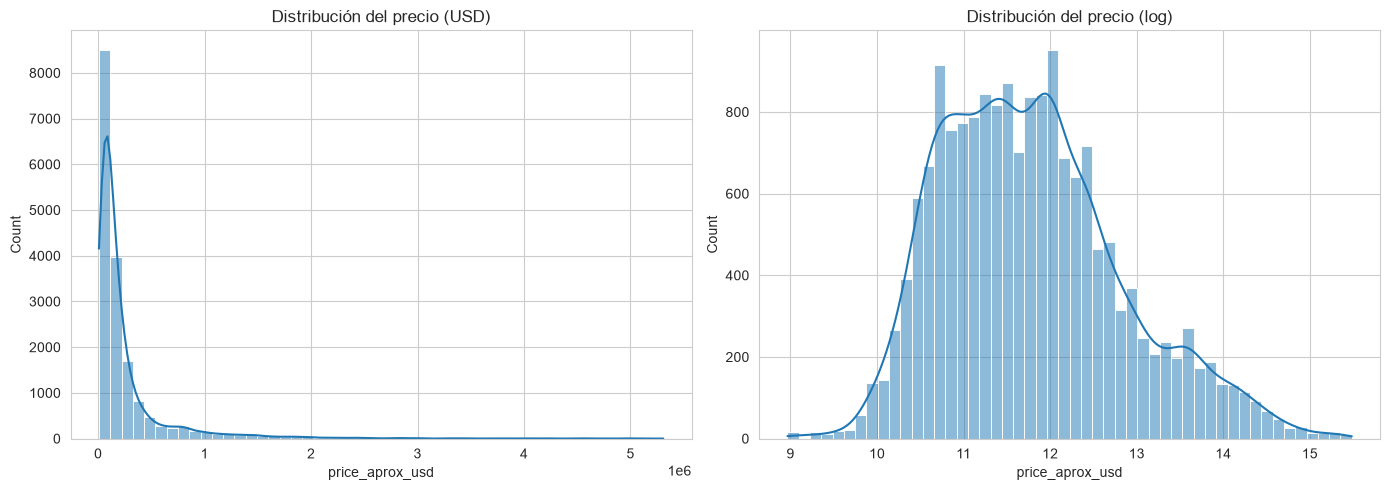

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución del precio (variable objetivo)
sns.histplot(df_cdmx['price_aprox_usd'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribución del precio (USD)')

# Lo mismo pero con log — para ver si el precio es log-normal (muy común en vivienda)
sns.histplot(np.log1p(df_cdmx['price_aprox_usd']), bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribución del precio (log)')

plt.tight_layout()
plt.show()

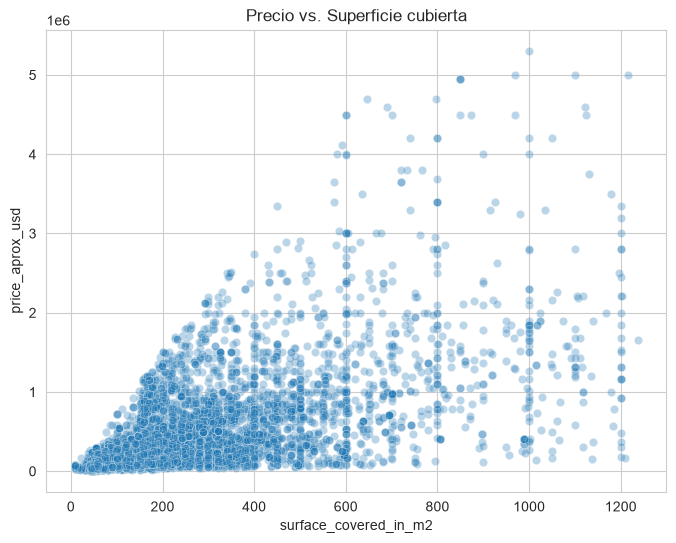

In [37]:
# Relación precio vs. superficie — la relación más importante para el modelo
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cdmx, x='surface_covered_in_m2', y='price_aprox_usd', alpha=0.3)
plt.title('Precio vs. Superficie cubierta')
plt.show()

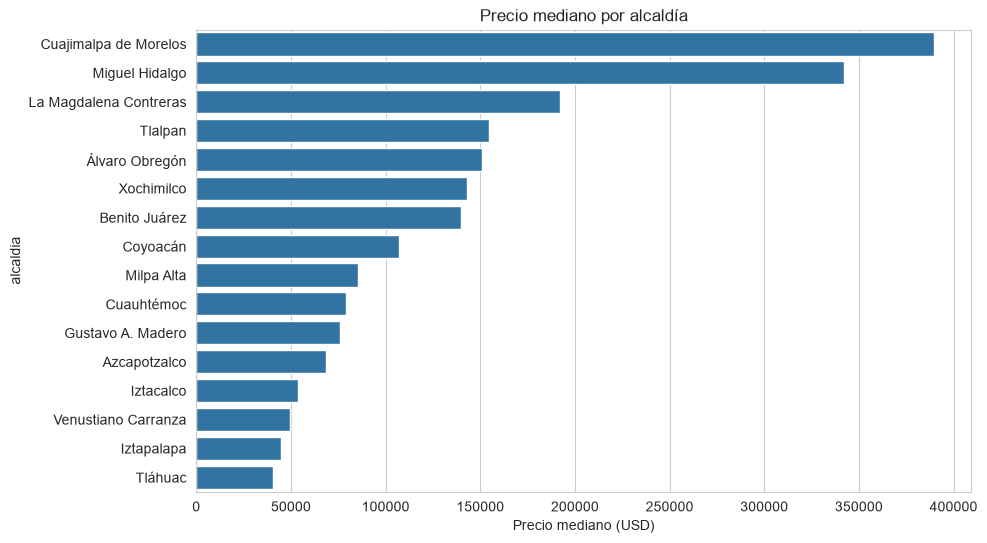

In [44]:
# Precio promedio por alcaldía — top 10 más caras
precio_por_alcaldia = df_cdmx.groupby('alcaldia')['price_aprox_usd'].median().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=precio_por_alcaldia.values, y=precio_por_alcaldia.index)
plt.title('Precio mediano por alcaldía')
plt.xlabel('Precio mediano (USD)')
plt.show()

# Paso 4: Feature engineering y encoding

In [46]:
import numpy as np

# 1. Variable objetivo en log — la vamos a usar para el modelo
df_cdmx['log_price'] = np.log1p(df_cdmx['price_aprox_usd'])

# 2. One-hot encoding de property_type y alcaldia
df_modelo = pd.get_dummies(df_cdmx, columns=['property_type', 'alcaldia'], drop_first=True)

print(df_modelo.shape)
print([c for c in df_modelo.columns if 'property_type' in c or 'alcaldia' in c])

(17312, 31)
['property_type_house', 'property_type_store', 'alcaldia_Benito Juárez', 'alcaldia_Coyoacán', 'alcaldia_Cuajimalpa de Morelos', 'alcaldia_Cuauhtémoc', 'alcaldia_Gustavo A. Madero', 'alcaldia_Iztacalco', 'alcaldia_Iztapalapa', 'alcaldia_La Magdalena Contreras', 'alcaldia_Miguel Hidalgo', 'alcaldia_Milpa Alta', 'alcaldia_Tlalpan', 'alcaldia_Tláhuac', 'alcaldia_Venustiano Carranza', 'alcaldia_Xochimilco', 'alcaldia_Álvaro Obregón']


In [47]:
# 3. Seleccionamos las columnas relevantes para el modelo (features + target)
features_numericas = ['surface_covered_in_m2', 'lat', 'lon']
features_dummies = [c for c in df_modelo.columns if 'property_type_' in c or 'alcaldia_' in c]

columnas_modelo = features_numericas + features_dummies + ['log_price']
df_final = df_modelo[columnas_modelo].copy()

print("Nulos antes de decidir tratamiento final:")
print(df_final.isnull().sum())

Nulos antes de decidir tratamiento final:
surface_covered_in_m2                 0
lat                                1972
lon                                1972
property_type_house                   0
property_type_store                   0
alcaldia_Benito Juárez                0
alcaldia_Coyoacán                     0
alcaldia_Cuajimalpa de Morelos        0
alcaldia_Cuauhtémoc                   0
alcaldia_Gustavo A. Madero            0
alcaldia_Iztacalco                    0
alcaldia_Iztapalapa                   0
alcaldia_La Magdalena Contreras       0
alcaldia_Miguel Hidalgo               0
alcaldia_Milpa Alta                   0
alcaldia_Tlalpan                      0
alcaldia_Tláhuac                      0
alcaldia_Venustiano Carranza          0
alcaldia_Xochimilco                   0
alcaldia_Álvaro Obregón               0
log_price                             0
dtype: int64


imputar lat/lon con la mediana de coordenadas dentro de esa misma alcaldía

In [48]:
# Imputamos lat/lon con la mediana de su propia alcaldía (más preciso que la mediana global)
df_cdmx['lat'] = df_cdmx.groupby('alcaldia')['lat'].transform(lambda x: x.fillna(x.median()))
df_cdmx['lon'] = df_cdmx.groupby('alcaldia')['lon'].transform(lambda x: x.fillna(x.median()))

print("Nulos restantes en lat:", df_cdmx['lat'].isna().sum())
print("Nulos restantes en lon:", df_cdmx['lon'].isna().sum())

Nulos restantes en lat: 0
Nulos restantes en lon: 0


In [49]:
# Por si algún grupo se quedó sin poder imputarse (grupo pequeño sin ningún dato de coordenada)
print(df_cdmx[df_cdmx['lat'].isna()][['alcaldia']].value_counts())

Series([], Name: count, dtype: int64)


In [50]:
# Respaldo: si aún quedan nulos, usamos la mediana global de CDMX
df_cdmx['lat'] = df_cdmx['lat'].fillna(df_cdmx['lat'].median())
df_cdmx['lon'] = df_cdmx['lon'].fillna(df_cdmx['lon'].median())

print("Nulos finales en lat/lon:", df_cdmx[['lat','lon']].isna().sum().sum())

Nulos finales en lat/lon: 0


In [51]:
df_modelo = pd.get_dummies(df_cdmx, columns=['property_type', 'alcaldia'], drop_first=True)

features_numericas = ['surface_covered_in_m2', 'lat', 'lon']
features_dummies = [c for c in df_modelo.columns if 'property_type_' in c or 'alcaldia_' in c]

columnas_modelo = features_numericas + features_dummies + ['log_price']
df_final = df_modelo[columnas_modelo].copy()

print(df_final.shape)
print(df_final.isnull().sum().sum(), "nulos totales")

(17312, 21)
0 nulos totales


# Paso 5: Split + modelo baseline

In [52]:
from sklearn.model_selection import train_test_split

X = df_final.drop(columns=['log_price'])
y = df_final['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (13849, 20)
Test: (3463, 20)


In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

y_pred_log = modelo_lr.predict(X_test)

# Métricas en escala log (la escala en la que entrenamos)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
r2 = r2_score(y_test, y_pred_log)

print(f"RMSE (log): {rmse_log:.4f}")
print(f"MAE (log): {mae_log:.4f}")
print(f"R²: {r2:.4f}")

RMSE (log): 0.6602
MAE (log): 0.5246
R²: 0.6070


In [54]:
# Traducimos las métricas a dólares reales (mucho más interpretable para el portafolio)
y_test_usd = np.expm1(y_test)
y_pred_usd = np.expm1(y_pred_log)

rmse_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))
mae_usd = mean_absolute_error(y_test_usd, y_pred_usd)

print(f"RMSE (USD): ${rmse_usd:,.0f}")
print(f"MAE (USD): ${mae_usd:,.0f}")

RMSE (USD): $503,166
MAE (USD): $156,769


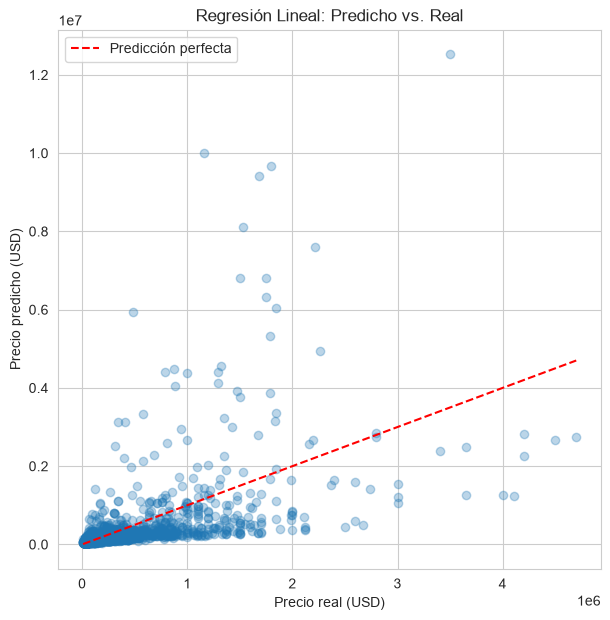

In [55]:
# Visualización: predicho vs. real (en USD, para que se entienda de un vistazo)
plt.figure(figsize=(7, 7))
plt.scatter(y_test_usd, y_pred_usd, alpha=0.3)
plt.plot([y_test_usd.min(), y_test_usd.max()], [y_test_usd.min(), y_test_usd.max()], 'r--', label='Predicción perfecta')
plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.title('Regresión Lineal: Predicho vs. Real')
plt.legend()
plt.show()

# Paso 6: Modelos más robustos

a) Ridge/Lasso (regularización, para ver si ayuda con la varianza sin cambiar de familia de modelo)

In [56]:
from sklearn.linear_model import Ridge, Lasso

modelo_ridge = Ridge(alpha=1.0, random_state=42)
modelo_ridge.fit(X_train, y_train)
pred_ridge = modelo_ridge.predict(X_test)

modelo_lasso = Lasso(alpha=0.01, random_state=42)
modelo_lasso.fit(X_train, y_train)
pred_lasso = modelo_lasso.predict(X_test)

for nombre, pred in [('Ridge', pred_ridge), ('Lasso', pred_lasso)]:
    r2_m = r2_score(y_test, pred)
    mae_usd_m = mean_absolute_error(np.expm1(y_test), np.expm1(pred))
    print(f"{nombre}: R²={r2_m:.4f}, MAE(USD)=${mae_usd_m:,.0f}")

Ridge: R²=0.6064, MAE(USD)=$156,554
Lasso: R²=0.5657, MAE(USD)=$170,507


b) Random Forest (el que probablemente resuelva el problema de las predicciones extremas):

In [58]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)
pred_rf_log = modelo_rf.predict(X_test)

r2_rf = r2_score(y_test, pred_rf_log)
mae_rf_usd = mean_absolute_error(np.expm1(y_test), np.expm1(pred_rf_log))
rmse_rf_usd = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(pred_rf_log)))

print(f"Random Forest: R²={r2_rf:.4f}, MAE(USD)=${mae_rf_usd:,.0f}, RMSE(USD)=${rmse_rf_usd:,.0f}")

Random Forest: R²=0.8585, MAE(USD)=$74,688, RMSE(USD)=$209,494


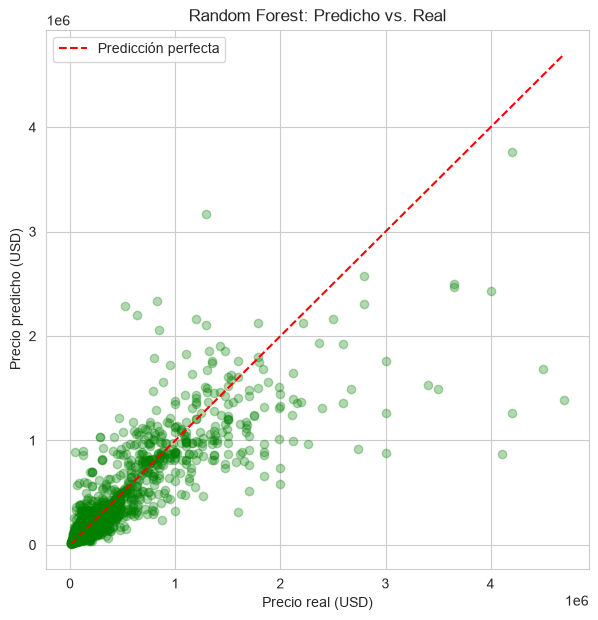

In [59]:
# Gráfica predicho vs. real para Random Forest — comparar directamente con la de regresión lineal
pred_rf_usd = np.expm1(pred_rf_log)
y_test_usd = np.expm1(y_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test_usd, pred_rf_usd, alpha=0.3, color='green')
plt.plot([y_test_usd.min(), y_test_usd.max()], [y_test_usd.min(), y_test_usd.max()], 'r--', label='Predicción perfecta')
plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.title('Random Forest: Predicho vs. Real')
plt.legend()
plt.show()

# Paso 7: XGBoost + feature importance

In [60]:
from xgboost import XGBRegressor

modelo_xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
modelo_xgb.fit(X_train, y_train)
pred_xgb_log = modelo_xgb.predict(X_test)

r2_xgb = r2_score(y_test, pred_xgb_log)
mae_xgb_usd = mean_absolute_error(np.expm1(y_test), np.expm1(pred_xgb_log))
rmse_xgb_usd = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(pred_xgb_log)))

print(f"XGBoost: R²={r2_xgb:.4f}, MAE(USD)=${mae_xgb_usd:,.0f}, RMSE(USD)=${rmse_xgb_usd:,.0f}")

XGBoost: R²=0.8444, MAE(USD)=$81,621, RMSE(USD)=$215,190


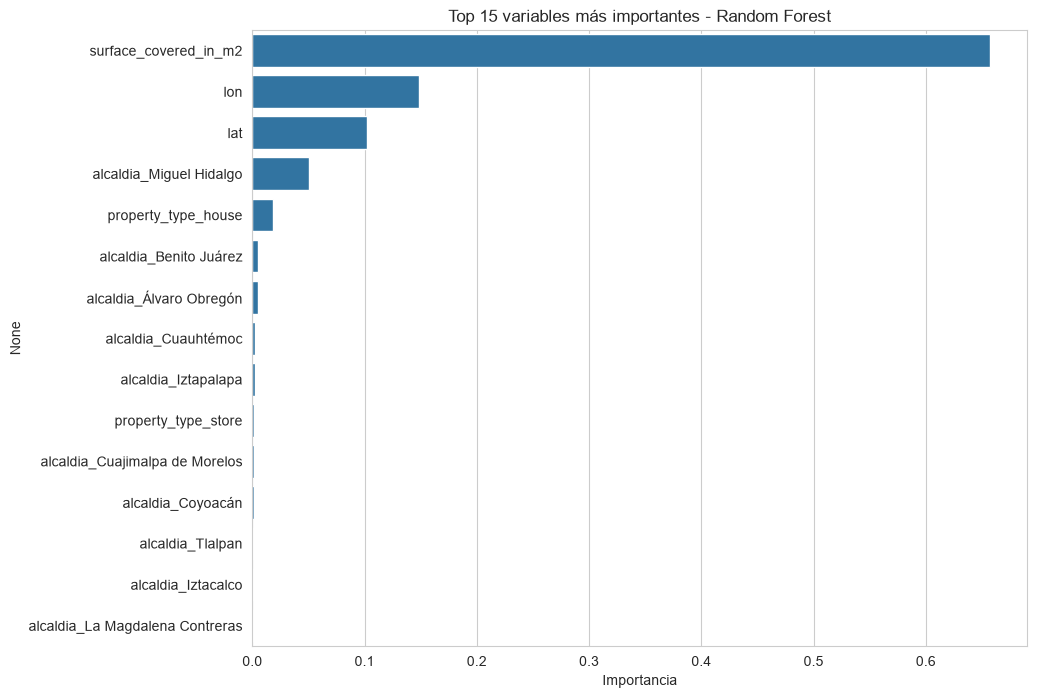

surface_covered_in_m2      0.657489
lon                        0.148809
lat                        0.102345
alcaldia_Miguel Hidalgo    0.050154
property_type_house        0.018261
alcaldia_Benito Juárez     0.005418
alcaldia_Álvaro Obregón    0.004761
alcaldia_Cuauhtémoc        0.002488
alcaldia_Iztapalapa        0.002260
property_type_store        0.001942
dtype: float64


In [61]:
# Feature importance de Random Forest (nuestro mejor modelo hasta ahora)
importancias = pd.Series(modelo_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importancias.head(15).values, y=importancias.head(15).index)
plt.title('Top 15 variables más importantes - Random Forest')
plt.xlabel('Importancia')
plt.show()

print(importancias.head(10))

## Conclusiones

Este proyecto predice el precio de venta de propiedades en CDMX (dataset Properati vía 
Kaggle, ~23,140 registros originales, 17,312 tras limpieza), evaluando distintos 
algoritmos de regresión y el impacto de transformaciones y feature engineering.

### Hallazgos principales

**1. La relación precio-características es fuertemente no lineal**
Modelos lineales (Regresión Lineal, Ridge, Lasso) alcanzaron R² de solo 0.57-0.61, con 
predicciones extremas hasta 4x el valor real en propiedades de alto precio. Random Forest 
mejoró el R² a 0.8585, reduciendo el MAE de $156,769 a $74,688 (-52%).

**2. El tamaño es, por mucho, el predictor más importante**
`surface_covered_in_m2` concentra ~65% de la importancia del modelo — más que 
ubicación y tipo de propiedad combinados.

**3. La ubicación exacta (lat/lon) supera a la alcaldía como categoría**
Latitud y longitud juntas explican ~25% de la importancia, mientras que las alcaldías 
individuales (excepto Miguel Hidalgo) aportan poco de forma aislada — sugiere que el 
precio varía más por micro-zona que por división administrativa.

**4. Cuajimalpa de Morelos, no Miguel Hidalgo, tiene el precio mediano más alto**
$390k vs $345k respectivamente — contraintuitivo frente a la percepción común de que 
Miguel Hidalgo (Polanco) es la zona más cara, probablemente por la presencia de 
desarrollos de lujo en Santa Fe/Bosques de las Lomas dentro de Cuajimalpa.

**5. Modelar en escala logarítmica fue clave**
El precio crudo estaba fuertemente sesgado a la derecha; usar log(precio) como variable 
objetivo permitió una distribución más simétrica y mejoró el ajuste de todos los modelos.

### Consideraciones metodológicas
- Limpieza extensa: filtrado por estado (dataset incluía otros estados pese al nombre), 
  corrección de coordenadas fuera de rango geográfico, eliminación de superficie/precio 
  por m² fuera de percentiles razonables (0.5%-99.5%).
- Imputación de coordenadas faltantes (11.4% de los datos) usando la mediana por alcaldía, 
  en vez de la mediana global, para mayor precisión geográfica.
- Ningún modelo de árboles superó claramente al otro de forma universal: Random Forest 
  superó a XGBoost en este dataset específico (contrario al proyecto de Classification), 
  recordando que no hay un "mejor modelo" absoluto sin probar.

### Posibles siguientes pasos
- GridSearch/RandomSearch de hiperparámetros para XGBoost (podría cerrar la brecha con RF).
- Feature engineering adicional: distancia al Centro/zonas de interés, densidad de 
  propiedades por zona (clustering geográfico).
- Modelo separado por tipo de propiedad (apartment vs. house), dado que sus dinámicas 
  de precio podrían diferir.